In [1]:
#!/usr/bin/env python3

from pathlib import Path
import re
import shutil
import numpy as np
from scipy.io import wavfile
import os
import stat
import time

# =========================================================
# SETTINGS
# =========================================================
ROOT = Path(".").resolve()

TEST_DIR = ROOT / "test_C_hjem"
TEST_SPLICED_DIR = TEST_DIR / "spliced"
TEST_READY_DIR = ROOT / "test_ready"

TARGET_LABELS = ["får", "ged", "hest", "laks", "ulv"]
OPTIONAL_UNKNOWN_LABELS = ["stilhed", "unknown"]

WINDOW_S = 1.00
PRE_S = 0.20
MIN_GAP_S = 0.45
FRAME_MS = 20
HOP_MS = 10
THRESH_MULT = 6.0
MAX_SLICES_PER_FILE = 10

# Hvis enkelte testfiler skal tunes særskilt, kan de sættes her
SPECIAL_FILE_PARAMS = {
    # "test_får_C_ukendt_tmlKlasse.001.wav": {
    #     "window_s": 1.0,
    #     "pre_s": 0.22,
    #     "min_gap_s": 0.55,
    #     "frame_ms": 20,
    #     "hop_ms": 10,
    #     "thresh_mult": 4.5,
    #     "max_slices": 2,
    # },
}

# Matcher fx:
# test_får_C_ukendt_tmlKlasse.001.wav
# test_stilhed_ukendt_tmlKlasse.001.wav  (uden speaker)
TEST_FNAME_RE = re.compile(
    r"^test_(?P<label>[^_]+)"
    r"(?:_(?P<speaker>[A-Za-z]))?"
    r"_(?P<dist>[^_]+)"
    r"_(?P<env>[^.]+)"
    r"\.(?P<take>\d+)\.wav$",
    re.IGNORECASE
)

# Matcher splicede testfiler:
# test_får_C_ukendt_tmlKlasse_001_s01.wav
TEST_SPLICED_RE = re.compile(
    r"^test_(?P<label>[^_]+)"
    r"(?:_(?P<speaker>[A-Za-z]))?"
    r"_(?P<dist>[^_]+)"
    r"_(?P<env>[^_]+)"
    r"_(?P<take>\d+)_s(?P<slice>\d+)\.wav$",
    re.IGNORECASE
)

# =========================================================
# HELPERS
# =========================================================
def sanitize(s: str) -> str:
    s = s.strip()
    return re.sub(r'[\\/:*?"<>|]+', "_", s)

def to_mono(x: np.ndarray) -> np.ndarray:
    if x.ndim == 1:
        return x
    return x.mean(axis=1)

def _handle_remove_readonly(func, path, exc):
    try:
        os.chmod(path, stat.S_IWRITE)
        func(path)
    except Exception as e:
        print(f"[cleanup] Could not delete {path}: {e}")

def safe_rmtree(path: Path, retries: int = 5, delay: float = 0.5):
    if not path.exists():
        return

    for attempt in range(1, retries + 1):
        try:
            shutil.rmtree(path, onerror=_handle_remove_readonly)
            return
        except PermissionError as e:
            print(f"[cleanup] PermissionError deleting {path} (attempt {attempt}/{retries}): {e}")
            time.sleep(delay)

    raise PermissionError(f"Could not delete folder after {retries} attempts: {path}")

def ensure_clean_dir(path: Path):
    if path.exists():
        safe_rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def moving_rms(x: np.ndarray, frame: int, hop: int) -> np.ndarray:
    if len(x) < frame:
        return np.array([], dtype=np.float32)
    n = 1 + (len(x) - frame) // hop
    rms = np.empty(n, dtype=np.float32)
    for i in range(n):
        seg = x[i * hop : i * hop + frame]
        rms[i] = np.sqrt(np.mean(seg * seg) + 1e-12)
    return rms

def detect_event_starts(rms: np.ndarray, thr: float, hop: int) -> np.ndarray:
    if rms.size == 0:
        return np.array([], dtype=np.int64)
    above = rms > thr
    starts = np.where(np.logical_and(above, np.concatenate([[False], ~above[:-1]])))[0]
    return (starts * hop).astype(np.int64)

def parse_test_base_name(wav_path: Path) -> str:
    m = TEST_FNAME_RE.match(wav_path.name)
    if m:
        label = sanitize(m.group("label"))
        speaker = m.group("speaker")
        dist = sanitize(m.group("dist"))
        env = sanitize(m.group("env"))
        take = int(m.group("take"))

        if speaker:
            speaker = sanitize(speaker)
            return f"test_{label}_{speaker}_{dist}_{env}_{take:03d}"
        else:
            return f"test_{label}_{dist}_{env}_{take:03d}"

    return sanitize(wav_path.stem)

# =========================================================
# STEP 1: SPLICE TEST FILES
# =========================================================
def slice_test_file(wav_path: Path, out_dir: Path, cfg: dict) -> int:
    fs, data = wavfile.read(wav_path)
    x = to_mono(data).astype(np.float32)

    frame = int(fs * (cfg["frame_ms"] / 1000.0))
    hop = int(fs * (cfg["hop_ms"] / 1000.0))

    rms = moving_rms(x, frame, hop)
    if rms.size == 0:
        return 0

    med = float(np.median(rms))
    thr = max(med * cfg["thresh_mult"], 1e-6)

    starts = detect_event_starts(rms, thr, hop)

    min_gap = int(fs * cfg["min_gap_s"])
    filtered = []
    last = -10**18
    for s in starts:
        if s - last >= min_gap:
            filtered.append(s)
            last = s
        if len(filtered) >= cfg["max_slices"]:
            break

    if not filtered:
        return 0

    base = parse_test_base_name(wav_path)
    out_dir.mkdir(parents=True, exist_ok=True)

    win = int(fs * cfg["window_s"])
    pre = int(fs * cfg["pre_s"])

    written = 0
    for i, s in enumerate(filtered, start=1):
        start = max(int(s - pre), 0)
        end = start + win
        if end > len(x):
            continue

        clip = x[start:end]
        clip = np.clip(clip, -32768, 32767).astype(np.int16)

        out_path = out_dir / f"{base}_s{i:02d}.wav"
        wavfile.write(out_path, fs, clip)
        written += 1

    return written

def slice_test_file_no_threshold(wav_path: Path, out_dir: Path) -> int:
    fs, data = wavfile.read(wav_path)
    x = to_mono(data).astype(np.int16)

    samples_per_chunk = int(fs * WINDOW_S)
    n_chunks = len(x) // samples_per_chunk

    base = parse_test_base_name(wav_path)
    out_dir.mkdir(parents=True, exist_ok=True)

    written = 0
    for i in range(n_chunks):
        start = i * samples_per_chunk
        end = start + samples_per_chunk
        clip = x[start:end]

        out_path = out_dir / f"{base}_s{i+1:02d}.wav"
        wavfile.write(out_path, fs, clip)
        written += 1

    return written

def splice_test():
    ensure_clean_dir(TEST_SPLICED_DIR)

    wavs = sorted([p for p in TEST_DIR.glob("*.wav") if p.is_file()])
    print(f"[test] Found {len(wavs)} raw test files")

    total = 0
    default_cfg = {
        "window_s": WINDOW_S,
        "pre_s": PRE_S,
        "min_gap_s": MIN_GAP_S,
        "frame_ms": FRAME_MS,
        "hop_ms": HOP_MS,
        "thresh_mult": THRESH_MULT,
        "max_slices": MAX_SLICES_PER_FILE,
    }

    for wav in wavs:
        cfg = SPECIAL_FILE_PARAMS.get(wav.name, default_cfg)

        # Hvis filen er stilhed, så slice uden threshold
        if wav.name.lower().startswith("test_stilhed_"):
            n = slice_test_file_no_threshold(wav, TEST_SPLICED_DIR)
            print(f"[test][no-threshold] {wav.name}: {n} slices")
        else:
            n = slice_test_file(wav, TEST_SPLICED_DIR, cfg)
            print(f"[test] {wav.name}: {n} slices")

        total += n

    print(f"[test] Total slices: {total}")

# =========================================================
# STEP 2: ORGANIZE TEST SLICES BY LABEL
# =========================================================
def build_test_ready():
    ensure_clean_dir(TEST_READY_DIR)

    labels_to_make = TARGET_LABELS + ["unknown"]
    for label in labels_to_make:
        (TEST_READY_DIR / label).mkdir(parents=True, exist_ok=True)

    wavs = sorted([p for p in TEST_SPLICED_DIR.glob("*.wav") if p.is_file()])
    moved = 0

    for wav in wavs:
        m = TEST_SPLICED_RE.match(wav.name)
        if not m:
            print(f"[test_ready] Could not parse filename: {wav.name}")
            continue

        label = m.group("label")

        # fold stilhed ind i unknown
        if label == "stilhed":
            label = "unknown"

        # alt ukendt kan også foldes ind i unknown
        if label not in TARGET_LABELS:
            label = "unknown"

        shutil.copy2(wav, TEST_READY_DIR / label / wav.name)
        moved += 1

    print(f"[test_ready] Copied {moved} files")
    for label in labels_to_make:
        count = len(list((TEST_READY_DIR / label).glob("*.wav")))
        print(f"[test_ready] {label}: {count} files")

# =========================================================
# MAIN
# =========================================================
def main():
    splice_test()
    build_test_ready()
    print("\nTest pipeline complete.")

if __name__ == "__main__":
    main()

[test] Found 12 raw test files
[test] test_får_C_0.75m_Chjem.002.wav: 10 slices
[test] test_får_C_1.5m_Chjem.002.wav: 10 slices
[test] test_ged_C_0.75m_Chjem.002.wav: 10 slices
[test] test_ged_C_1.5m_Chjem.002.wav: 10 slices
[test] test_hest_C_0.75m_Chjem.002.wav: 10 slices
[test] test_hest_C_1.5m_Chjem.002.wav: 10 slices
[test] test_laks_C_0.75m_Chjem.002.wav: 10 slices
[test] test_laks_C_1.5m_Chjem.002.wav: 10 slices
[test] test_random_C_ukendt_Chjem.002.wav: 10 slices
[test][no-threshold] test_stilhed_C_ukendt_Chjem.002.wav: 30 slices
[test] test_ulv_C_0.75m_Chjem.002.wav: 10 slices
[test] test_ulv_C_1.5m_Chjem.002.wav: 10 slices
[test] Total slices: 140
[test_ready] Copied 140 files
[test_ready] får: 20 files
[test_ready] ged: 20 files
[test_ready] hest: 20 files
[test_ready] laks: 20 files
[test_ready] ulv: 20 files
[test_ready] unknown: 40 files

Test pipeline complete.



Model: LogisticRegression, Features: simple [FFT_N=4096]
Number of features: 9
Accuracy: 0.38571428571428573
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        20
         ged       0.00      0.00      0.00        20
        hest       0.45      0.75      0.57        20
        laks       1.00      0.05      0.10        20
         ulv       0.00      0.00      0.00        20
     unknown       0.37      0.95      0.53        40

    accuracy                           0.39       140
   macro avg       0.30      0.29      0.20       140
weighted avg       0.31      0.39      0.25       140



c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

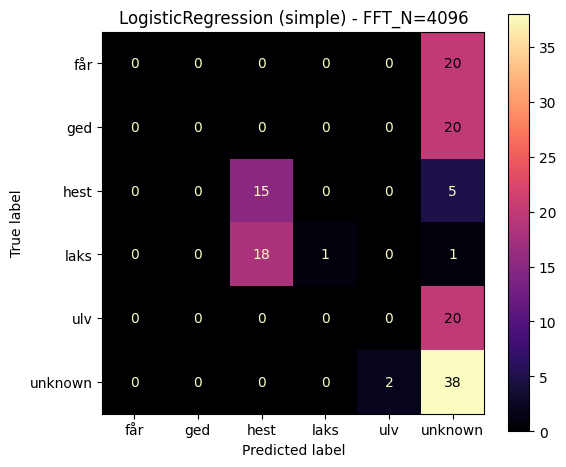


Model: LinearSVM, Features: simple [FFT_N=4096]
Number of features: 9
Accuracy: 0.35
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        20
         ged       0.00      0.00      0.00        20
        hest       0.32      0.40      0.36        20
        laks       1.00      0.10      0.18        20
         ulv       0.00      0.00      0.00        20
     unknown       0.35      0.97      0.51        40

    accuracy                           0.35       140
   macro avg       0.28      0.25      0.18       140
weighted avg       0.29      0.35      0.22       140



c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

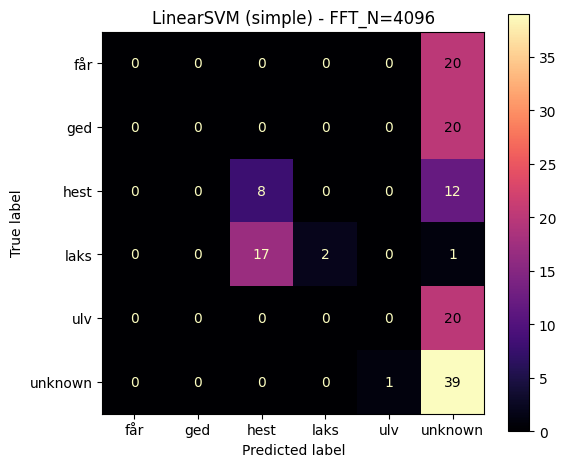


Model: RandomForest, Features: simple [FFT_N=4096]
Number of features: 9
Accuracy: 0.4
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        20
         ged       1.00      0.10      0.18        20
        hest       1.00      0.15      0.26        20
        laks       1.00      0.55      0.71        20
         ulv       0.00      0.00      0.00        20
     unknown       0.32      1.00      0.49        40

    accuracy                           0.40       140
   macro avg       0.55      0.30      0.27       140
weighted avg       0.52      0.40      0.30       140



c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

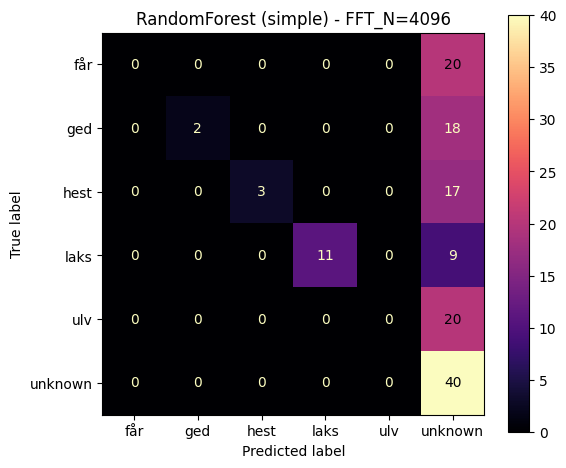


Model: LogisticRegression, Features: mfcc [FFT_N=4096]
Number of features: 13
Accuracy: 0.5571428571428572
              precision    recall  f1-score   support

         får       1.00      0.05      0.10        20
         ged       1.00      0.65      0.79        20
        hest       0.77      0.50      0.61        20
        laks       0.90      0.45      0.60        20
         ulv       0.78      0.35      0.48        20
     unknown       0.40      0.95      0.57        40

    accuracy                           0.56       140
   macro avg       0.81      0.49      0.52       140
weighted avg       0.75      0.56      0.53       140



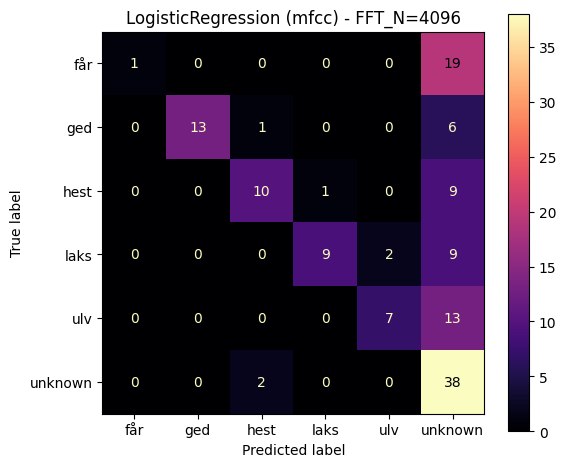


Model: LinearSVM, Features: mfcc [FFT_N=4096]
Number of features: 13
Accuracy: 0.5
              precision    recall  f1-score   support

         får       1.00      0.05      0.10        20
         ged       1.00      0.70      0.82        20
        hest       1.00      0.05      0.10        20
        laks       0.88      0.35      0.50        20
         ulv       0.88      0.35      0.50        20
     unknown       0.37      1.00      0.54        40

    accuracy                           0.50       140
   macro avg       0.85      0.42      0.43       140
weighted avg       0.78      0.50      0.44       140



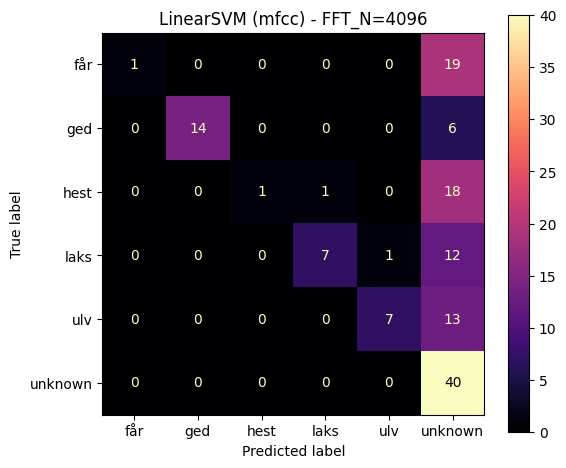


Model: RandomForest, Features: mfcc [FFT_N=4096]
Number of features: 13
Accuracy: 0.5714285714285714
              precision    recall  f1-score   support

         får       1.00      0.50      0.67        20
         ged       0.92      0.55      0.69        20
        hest       1.00      0.45      0.62        20
        laks       0.00      0.00      0.00        20
         ulv       1.00      0.50      0.67        20
     unknown       0.40      1.00      0.58        40

    accuracy                           0.57       140
   macro avg       0.72      0.50      0.54       140
weighted avg       0.67      0.57      0.54       140



c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

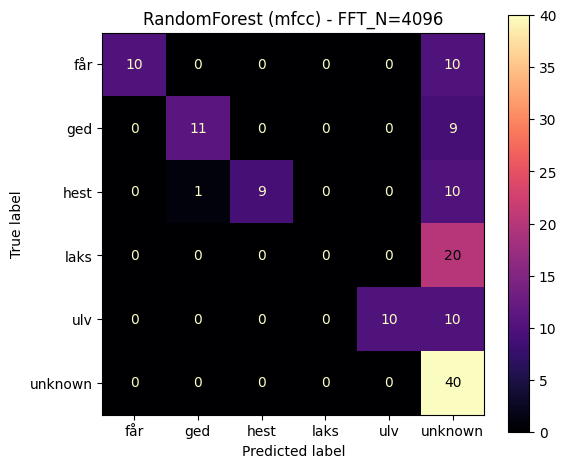


Model: LogisticRegression, Features: mel [FFT_N=4096]
Number of features: 20
Accuracy: 0.2857142857142857
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        20
         ged       0.00      0.00      0.00        20
        hest       0.00      0.00      0.00        20
        laks       0.00      0.00      0.00        20
         ulv       0.00      0.00      0.00        20
     unknown       0.29      1.00      0.44        40

    accuracy                           0.29       140
   macro avg       0.05      0.17      0.07       140
weighted avg       0.08      0.29      0.13       140



c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

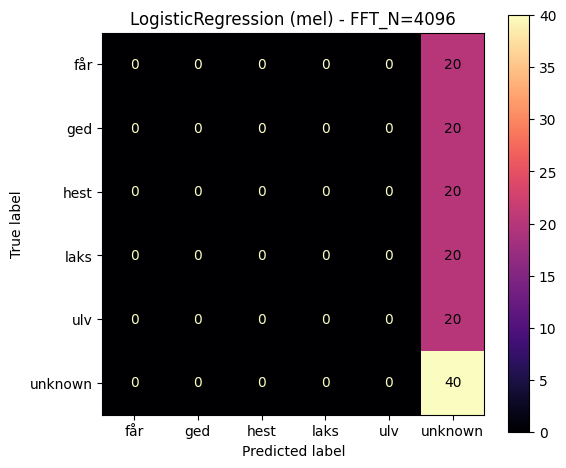


Model: LinearSVM, Features: mel [FFT_N=4096]
Number of features: 20
Accuracy: 0.2857142857142857
              precision    recall  f1-score   support

         får       0.00      0.00      0.00        20
         ged       0.00      0.00      0.00        20
        hest       0.00      0.00      0.00        20
        laks       0.00      0.00      0.00        20
         ulv       0.00      0.00      0.00        20
     unknown       0.29      1.00      0.44        40

    accuracy                           0.29       140
   macro avg       0.05      0.17      0.07       140
weighted avg       0.08      0.29      0.13       140



c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

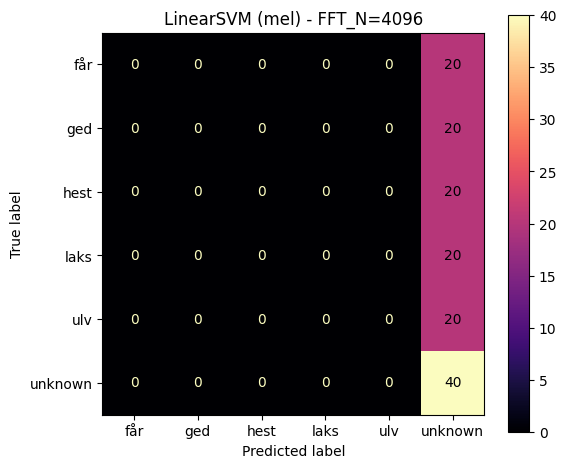


Model: RandomForest, Features: mel [FFT_N=4096]
Number of features: 20
Accuracy: 0.5214285714285715
              precision    recall  f1-score   support

         får       1.00      0.30      0.46        20
         ged       1.00      0.45      0.62        20
        hest       0.93      0.65      0.76        20
        laks       0.00      0.00      0.00        20
         ulv       1.00      0.25      0.40        20
     unknown       0.38      1.00      0.55        40

    accuracy                           0.52       140
   macro avg       0.72      0.44      0.47       140
weighted avg       0.67      0.52      0.48       140



c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

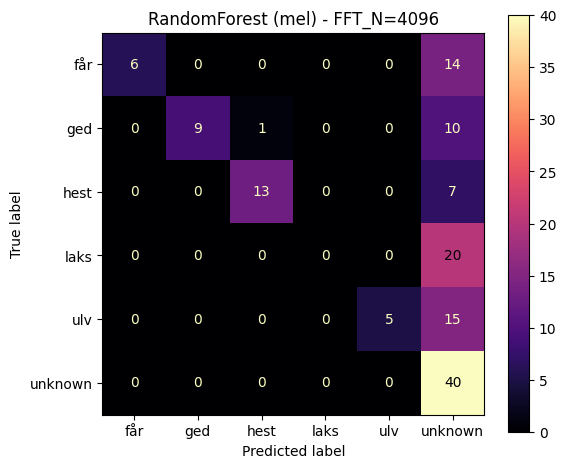


Model: LogisticRegression, Features: mfcc_mel [FFT_N=4096]
Number of features: 33
Accuracy: 0.6428571428571429
              precision    recall  f1-score   support

         får       1.00      0.30      0.46        20
         ged       1.00      0.75      0.86        20
        hest       0.89      0.80      0.84        20
        laks       1.00      0.35      0.52        20
         ulv       0.88      0.35      0.50        20
     unknown       0.45      0.97      0.62        40

    accuracy                           0.64       140
   macro avg       0.87      0.59      0.63       140
weighted avg       0.81      0.64      0.63       140



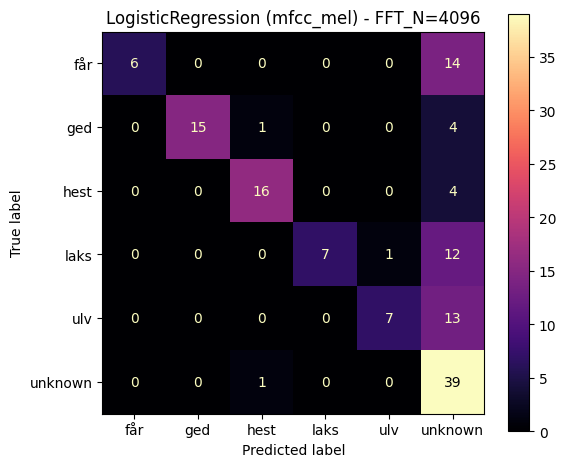


Model: LinearSVM, Features: mfcc_mel [FFT_N=4096]
Number of features: 33
Accuracy: 0.6714285714285714
              precision    recall  f1-score   support

         får       1.00      0.40      0.57        20
         ged       1.00      0.95      0.97        20
        hest       0.95      0.95      0.95        20
        laks       1.00      0.20      0.33        20
         ulv       0.83      0.25      0.38        20
     unknown       0.47      0.97      0.63        40

    accuracy                           0.67       140
   macro avg       0.88      0.62      0.64       140
weighted avg       0.82      0.67      0.64       140



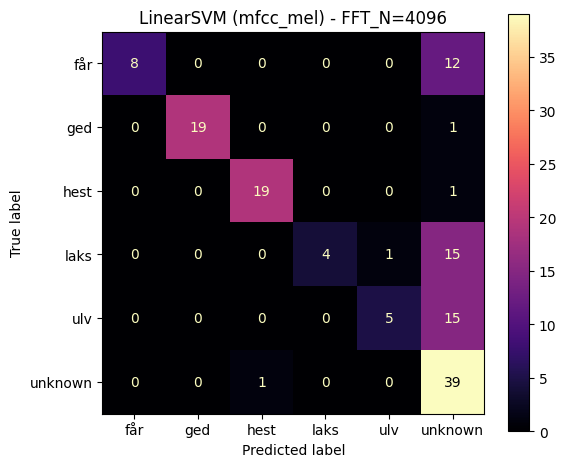


Model: RandomForest, Features: mfcc_mel [FFT_N=4096]
Number of features: 33
Accuracy: 0.5857142857142857
              precision    recall  f1-score   support

         får       1.00      0.35      0.52        20
         ged       1.00      0.60      0.75        20
        hest       1.00      0.70      0.82        20
        laks       0.00      0.00      0.00        20
         ulv       1.00      0.45      0.62        20
     unknown       0.41      1.00      0.58        40

    accuracy                           0.59       140
   macro avg       0.73      0.52      0.55       140
weighted avg       0.69      0.59      0.55       140



c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\anaconda3\envs\tinyml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

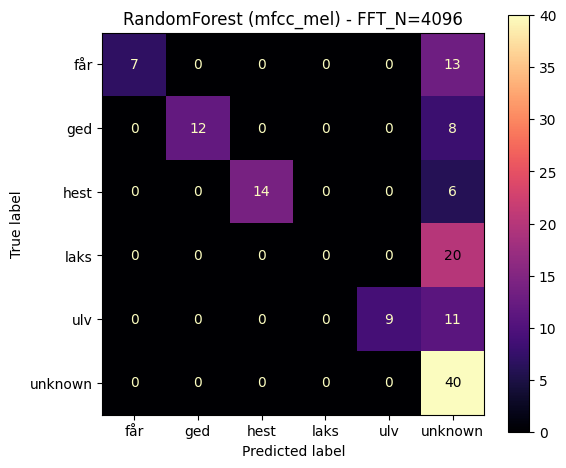


Model: LogisticRegression, Features: combined [FFT_N=4096]
Number of features: 42
Accuracy: 0.6714285714285714
              precision    recall  f1-score   support

         får       1.00      0.40      0.57        20
         ged       1.00      0.40      0.57        20
        hest       1.00      0.95      0.97        20
        laks       1.00      0.75      0.86        20
         ulv       1.00      0.20      0.33        20
     unknown       0.47      1.00      0.63        40

    accuracy                           0.67       140
   macro avg       0.91      0.62      0.66       140
weighted avg       0.85      0.67      0.65       140



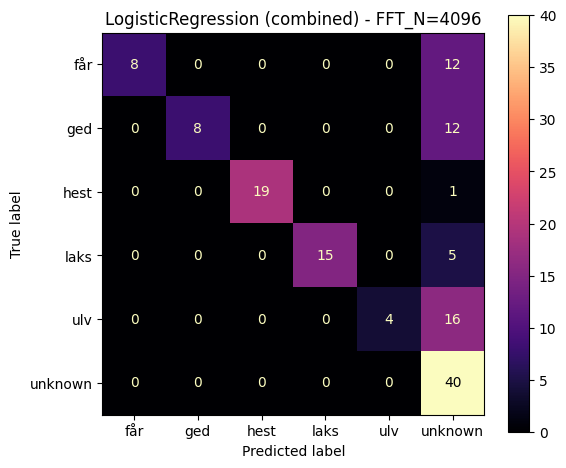


Model: LinearSVM, Features: combined [FFT_N=4096]
Number of features: 42
Accuracy: 0.6714285714285714
              precision    recall  f1-score   support

         får       1.00      0.60      0.75        20
         ged       0.89      0.40      0.55        20
        hest       1.00      0.85      0.92        20
        laks       1.00      0.75      0.86        20
         ulv       1.00      0.15      0.26        20
     unknown       0.46      0.97      0.63        40

    accuracy                           0.67       140
   macro avg       0.89      0.62      0.66       140
weighted avg       0.83      0.67      0.66       140



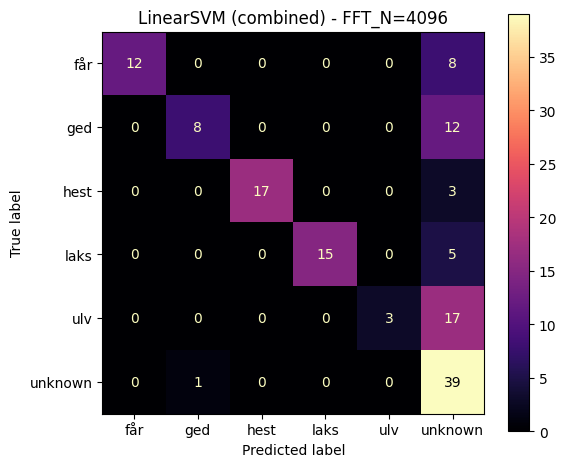


Model: RandomForest, Features: combined [FFT_N=4096]
Number of features: 42
Accuracy: 0.4785714285714286
              precision    recall  f1-score   support

         får       1.00      0.05      0.10        20
         ged       1.00      0.45      0.62        20
        hest       1.00      0.15      0.26        20
        laks       1.00      0.55      0.71        20
         ulv       1.00      0.15      0.26        20
     unknown       0.35      1.00      0.52        40

    accuracy                           0.48       140
   macro avg       0.89      0.39      0.41       140
weighted avg       0.82      0.48      0.43       140



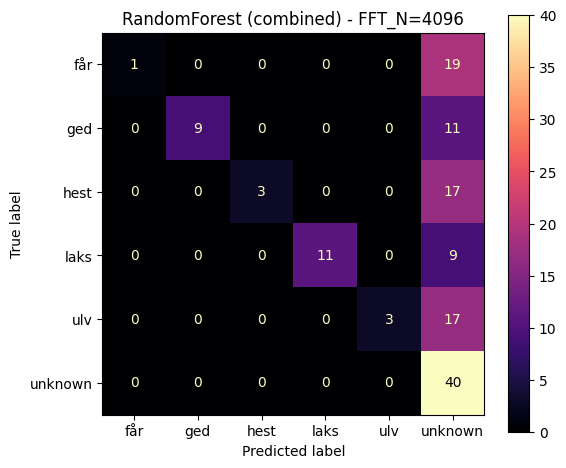


Summary:
                 model  features  n_features  accuracy
13           LinearSVM  combined          42  0.671429
12  LogisticRegression  combined          42  0.671429
10           LinearSVM  mfcc_mel          33  0.671429
9   LogisticRegression  mfcc_mel          33  0.642857
11        RandomForest  mfcc_mel          33  0.585714
5         RandomForest      mfcc          13  0.571429
3   LogisticRegression      mfcc          13  0.557143
8         RandomForest       mel          20  0.521429
4            LinearSVM      mfcc          13  0.500000
14        RandomForest  combined          42  0.478571
2         RandomForest    simple           9  0.400000
0   LogisticRegression    simple           9  0.385714
1            LinearSVM    simple           9  0.350000
6   LogisticRegression       mel          20  0.285714
7            LinearSVM       mel          20  0.285714


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    accuracy_score,
    classification_report,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# =========================
# SETTINGS
# =========================
TRAIN_KEYWORDS_DIR = Path("prepared_words")
TRAIN_UNKNOWN_DIR = Path("unknown_balanced")
TEST_DIR = Path("test_ready")

KEYWORD_LABELS = ["får", "ged", "hest", "laks", "ulv"]
ALL_LABELS = KEYWORD_LABELS + ["unknown"]

SAMPLE_RATE = 16000
FFT_N = 4096
N_MELS = 20
N_MFCC = 13
EPS = 1e-12

# =========================
# AUDIO / FEATURE FUNCTIONS
# =========================
def load_wav(path: Path):
    x, fs = sf.read(str(path), always_2d=False)
    x = np.asarray(x, dtype=np.float32)

    if x.ndim > 1:
        x = x.mean(axis=1)

    if fs != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate in {path}: {fs}")

    peak = np.max(np.abs(x)) + 1e-9
    x = x / peak
    return x

def prepare_fft_frame(x: np.ndarray, fft_n: int = FFT_N) -> np.ndarray:
    frame = np.zeros(fft_n, dtype=np.float32)
    copy_len = min(len(x), fft_n)
    frame[:copy_len] = x[:copy_len]

    window = np.hanning(fft_n).astype(np.float32)
    frame *= window
    return frame

def magnitude_spectrum(x, fs, fft_n: int = FFT_N):
    frame = prepare_fft_frame(x, fft_n=fft_n)
    spec = np.fft.rfft(frame)
    mag = np.abs(spec).astype(np.float32)
    freqs = np.fft.rfftfreq(fft_n, d=1 / fs).astype(np.float32)
    return freqs, mag

def fft_real_only_power_emlearn_style(x, fs, fft_n: int = FFT_N):
    """
    Matcher eml_audio_power_spectrogram():
    bruger kun realdel af FFT-output og skalerer med 1/n_fft
    """
    frame = prepare_fft_frame(x, fft_n=fft_n)
    spec = np.fft.rfft(frame)
    real_part = np.real(spec).astype(np.float32)
    power = (np.abs(real_part) ** 2) / float(fft_n)
    freqs = np.fft.rfftfreq(fft_n, d=1 / fs).astype(np.float32)
    return freqs, power

def hz_to_mel(hz: float) -> float:
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mels: float) -> float:
    return 700.0 * (10.0 ** (mels / 2595.0) - 1.0)

def eml_audio_mel_center(n: int, n_mels: int, fmin: float, fmax: float) -> float:
    melmin = hz_to_mel(fmin)
    melmax = hz_to_mel(fmax)
    melstep = (melmax - melmin) / (n_mels + 1)
    mel = melmin + (n * melstep)
    return mel_to_hz(mel)

def eml_audio_mel_bin(hz: float, n_fft: int, samplerate: float) -> int:
    return int(np.floor((n_fft + 1) * (hz / samplerate)))

def eml_fft_freq(k: int, n_fft: int, samplerate: float) -> float:
    end = samplerate / 2.0
    steps = (1 + n_fft // 2) - 1
    return (k * end) / steps

def mel_spectrum_emlearn_style(x, fs, n_mels=N_MELS, fft_n=FFT_N):
    _, spec = fft_real_only_power_emlearn_style(x, fs, fft_n=fft_n)

    fmin = 0.0
    fmax = fs / 2.0
    max_bin = 1 + fft_n // 2

    mels = np.zeros(n_mels, dtype=np.float32)

    for m in range(1, n_mels + 1):
        left_hz = eml_audio_mel_center(m - 1, n_mels, fmin, fmax)
        center_hz = eml_audio_mel_center(m, n_mels, fmin, fmax)
        right_hz = eml_audio_mel_center(m + 1, n_mels, fmin, fmax)

        left = eml_audio_mel_bin(left_hz, fft_n, fs)
        center = eml_audio_mel_bin(center_hz, fft_n, fs)
        right = eml_audio_mel_bin(right_hz, fft_n, fs)

        left = max(0, min(left, max_bin - 1))
        center = max(0, min(center, max_bin - 1))
        right = max(0, min(right, max_bin - 1))

        fdifflow = center_hz - left_hz
        fdiffupper = right_hz - center_hz

        val = 0.0

        for k in range(left, center + 1):
            r = left_hz - eml_fft_freq(k, fft_n, fs)
            weight = max(min(-r / fdifflow if fdifflow != 0 else 0.0, 1.0), 0.0)
            val += spec[k] * weight

        for k in range(center, right):
            if k + 1 >= len(spec):
                break
            r = right_hz - eml_fft_freq(k + 1, fft_n, fs)
            weight = max(min(r / fdiffupper if fdiffupper != 0 else 0.0, 1.0), 0.0)
            val += spec[k + 1] * weight

        mels[m - 1] = val

    return mels

def dct_type_2(x: np.ndarray, n_out: int) -> np.ndarray:
    n = len(x)
    out = np.zeros(n_out, dtype=np.float32)
    for k in range(n_out):
        s = 0.0
        for m in range(n):
            s += x[m] * np.cos(np.pi * k * (m + 0.5) / n)
        out[k] = s
    return out

def mfcc_features_emlearn_style(x, fs, n_mfcc=N_MFCC, n_mels=N_MELS, fft_n=FFT_N):
    mel = mel_spectrum_emlearn_style(x, fs, n_mels=n_mels, fft_n=fft_n)
    log_mel = np.log(mel + EPS)
    mfcc = dct_type_2(log_mel, n_mfcc)
    return mfcc.astype(np.float32)

def rms_energy(x):
    return float(np.sqrt(np.mean(x ** 2) + 1e-12))

def zero_crossing_rate(x):
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def spectral_centroid(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_rolloff(x, fs, roll_percent=0.85):
    freqs, mag = magnitude_spectrum(x, fs)
    cumsum = np.cumsum(mag)
    threshold = roll_percent * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    return float(freqs[min(idx, len(freqs) - 1)])

def dominant_frequency(x, fs):
    freqs, mag = magnitude_spectrum(x, fs)
    idx = np.argmax(mag[1:]) + 1 if len(mag) > 1 else 0
    return float(freqs[idx])

def band_energy(x, fs, f_low, f_high):
    freqs, mag = magnitude_spectrum(x, fs)
    power = mag ** 2
    mask = (freqs >= f_low) & (freqs < f_high)
    return float(np.sum(power[mask]))

def extract_features(x, fs):
    record = {
        "rms": rms_energy(x),
        "zcr": zero_crossing_rate(x),
        "centroid": spectral_centroid(x, fs),
        "rolloff": spectral_rolloff(x, fs),
        "dominant_freq": dominant_frequency(x, fs),
        "band_0_500": band_energy(x, fs, 0, 500),
        "band_500_1500": band_energy(x, fs, 500, 1500),
        "band_1500_3000": band_energy(x, fs, 1500, 3000),
        "band_3000_6000": band_energy(x, fs, 3000, 6000),
    }

    mel_vals = mel_spectrum_emlearn_style(x, fs, n_mels=N_MELS, fft_n=FFT_N)
    for i, val in enumerate(mel_vals, start=1):
        record[f"mel_{i}"] = float(val)

    mfcc_vals = mfcc_features_emlearn_style(x, fs, n_mfcc=N_MFCC, n_mels=N_MELS, fft_n=FFT_N)
    for i, val in enumerate(mfcc_vals, start=1):
        record[f"mfcc_{i}"] = float(val)

    return record

# =========================
# BUILD DATAFRAMES
# =========================
train_records = []

for label in KEYWORD_LABELS:
    for wav_path in sorted((TRAIN_KEYWORDS_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        train_records.append(record)

for wav_path in sorted(TRAIN_UNKNOWN_DIR.glob("*.wav")):
    x = load_wav(wav_path)
    record = extract_features(x, SAMPLE_RATE)
    record["activity"] = "unknown"
    record["filename"] = wav_path.name
    train_records.append(record)

train_df = pd.DataFrame(train_records)

test_records = []

for label in ALL_LABELS:
    for wav_path in sorted((TEST_DIR / label).glob("*.wav")):
        x = load_wav(wav_path)
        record = extract_features(x, SAMPLE_RATE)
        record["activity"] = label
        record["filename"] = wav_path.name
        test_records.append(record)

test_df = pd.DataFrame(test_records)

# =========================
# FEATURE SETS
# =========================
simple_features = [
    "rms", "zcr", "centroid", "rolloff", "dominant_freq",
    "band_0_500", "band_500_1500", "band_1500_3000", "band_3000_6000"
]
mel_feature_cols = [f"mel_{i}" for i in range(1, N_MELS + 1)]
mfcc_feature_cols = [f"mfcc_{i}" for i in range(1, N_MFCC + 1)]

feature_sets = {
    "simple": simple_features,
    "mfcc": mfcc_feature_cols,
    "mel": mel_feature_cols,
    "mfcc_mel": mfcc_feature_cols + mel_feature_cols,
    "combined": simple_features + mfcc_feature_cols + mel_feature_cols,
}

# =========================
# MODELS
# =========================
models = {
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000)
    ),
    "LinearSVM": make_pipeline(
        StandardScaler(),
        LinearSVC()
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42
    ),
}

# =========================
# TRAIN / EVALUATE
# =========================
results = []

for feat_name, feat_cols in feature_sets.items():
    X_train = train_df[feat_cols]
    y_train = train_df["activity"]

    X_test = test_df[feat_cols]
    y_test = test_df["activity"]

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "model": model_name,
            "features": feat_name,
            "n_features": len(feat_cols),
            "accuracy": acc
        })

        print(f"\nModel: {model_name}, Features: {feat_name} [FFT_N={FFT_N}]")
        print(f"Number of features: {len(feat_cols)}")
        print("Accuracy:", acc)
        print(classification_report(y_test, y_pred, labels=ALL_LABELS))

        cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=ALL_LABELS
        )

        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, cmap="magma", values_format="d")
        plt.title(f"{model_name} ({feat_name}) - FFT_N={FFT_N}")
        plt.tight_layout()
        plt.show()

results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df.sort_values("accuracy", ascending=False))